# Chapter 176 — Matrix Calculus Introduction

> **Prerequisites:** ch155 (Matrix Transpose), ch154 (Matrix Multiplication), ch168 (Projection Matrices)
> **Note:** Full calculus (derivatives, gradients) is covered in Part VII (ch201–240). This chapter introduces only the matrix-specific notation and identities needed for neural network math in ch177–178.
> **You will learn:**
> - Derivatives of scalar functions with respect to vectors and matrices
> - The gradient of the squared loss ||Ax - b||² with respect to x
> - Jacobian and its role in backpropagation
> - Key matrix derivative identities used in deep learning
> **Environment:** Python 3.x, numpy, matplotlib

## 1. Concept

Calculus on scalars: df/dx is the rate of change of f as x changes. Matrix calculus extends this to functions whose inputs or outputs are vectors and matrices.

Four types of derivative:

| Input | Output | Result | Name |
|-------|--------|--------|------|
| scalar | scalar | scalar | ordinary derivative |
| vector | scalar | vector | gradient |
| vector | vector | matrix | Jacobian |
| matrix | scalar | matrix | matrix gradient |

For neural networks, the critical case is: scalar loss function → gradient with respect to weight matrices. This gradient tells the optimizer which direction to move the weights.

**Convention:** This chapter uses the **denominator layout** convention (gradient is a column vector, same shape as input). Numerator layout (gradient is a row vector) is also common — be alert when reading papers.

## 2. Intuition & Mental Models

**Gradient as steepest ascent:** The gradient of f(x) at a point x is a vector pointing in the direction of steepest increase of f. To minimize f, move opposite to the gradient. This is gradient descent *(introduced in ch212 — Gradient Descent)*.

**Shape rule:** The gradient ∂f/∂x always has the same shape as x. If x is an n-vector, ∂f/∂x is an n-vector. If W is an m×n matrix, ∂f/∂W is an m×n matrix. This "shape matches input" rule is the fastest sanity check.

**Jacobian as stacked gradients:** If f: ℝⁿ → ℝᵐ, the Jacobian J is m×n — row i is the gradient of the i-th output with respect to all inputs.

Recall from ch168 that the projection Ax lives in the column space of A. The gradient of ||Ax - b||² pulls x toward b along that column space.

## 3. Visualization

C:\Users\user\AppData\Local\Temp\ipykernel_20416\3976537204.py:49: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_20416\3976537204.py:49: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\user\OneDrive\Documents\book\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\OneDrive\Documents\book\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


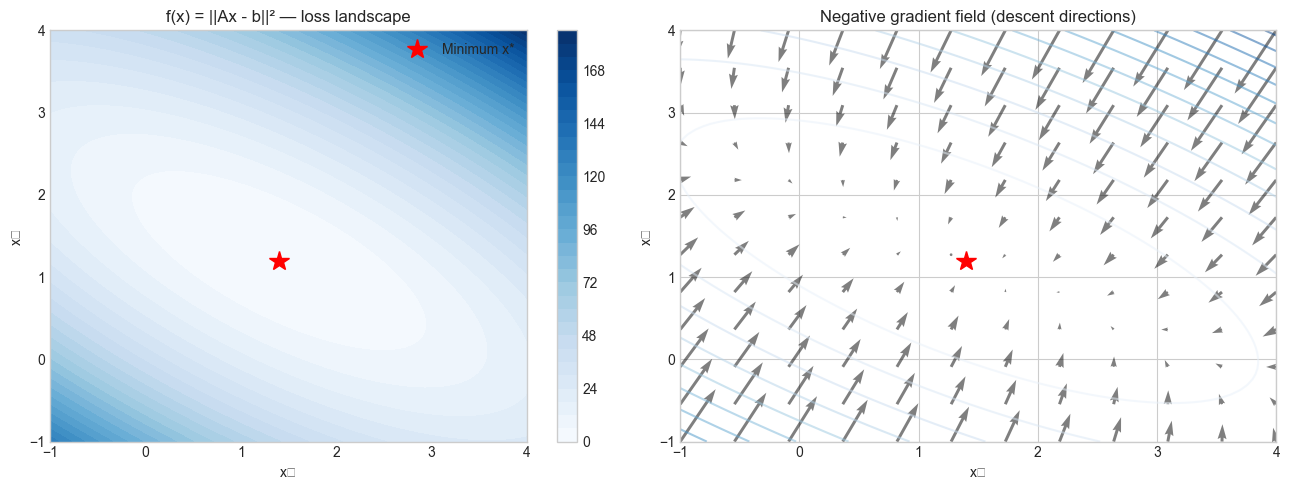

In [1]:
# --- Visualization: Gradient of ||Ax - b||^2 on a 2D grid ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

# Simple 2x2 case: f(x) = ||Ax - b||^2
A = np.array([[2.0, 1.0], [1.0, 3.0]])
b = np.array([4.0, 5.0])
x_star = np.linalg.solve(A.T @ A, A.T @ b)  # optimal x

# Evaluate f on a grid
x1 = np.linspace(-1, 4, 80)
x2 = np.linspace(-1, 4, 80)
X1, X2 = np.meshgrid(x1, x2)
F = np.zeros_like(X1)
for i in range(X1.shape[0]):
    for j in range(X1.shape[1]):
        x = np.array([X1[i,j], X2[i,j]])
        r = A @ x - b
        F[i,j] = r @ r

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Contour plot
ax = axes[0]
cs = ax.contourf(X1, X2, F, levels=30, cmap='Blues')
plt.colorbar(cs, ax=ax)
ax.plot(*x_star, 'r*', markersize=15, label='Minimum x*')
ax.set_xlabel('x₁'); ax.set_ylabel('x₂')
ax.set_title('f(x) = ||Ax - b||² — loss landscape')
ax.legend()

# Gradient field
ax2 = axes[1]
x1g = np.linspace(-1, 4, 12)
x2g = np.linspace(-1, 4, 12)
X1g, X2g = np.meshgrid(x1g, x2g)
# Gradient = 2 A^T (Ax - b)
ATA2 = 2 * A.T @ A
ATb2 = 2 * A.T @ b
G1 = ATA2[0,0]*X1g + ATA2[0,1]*X2g - ATb2[0]
G2 = ATA2[1,0]*X1g + ATA2[1,1]*X2g - ATb2[1]
ax2.quiver(X1g, X2g, -G1, -G2, alpha=0.5)  # negative gradient = descent direction
cs2 = ax2.contour(X1, X2, F, levels=15, cmap='Blues', alpha=0.5)
ax2.plot(*x_star, 'r*', markersize=15)
ax2.set_xlabel('x₁'); ax2.set_ylabel('x₂')
ax2.set_title('Negative gradient field (descent directions)')

plt.tight_layout()
plt.show()

## 4. Mathematical Formulation

**Key identities (denominator layout):**

    ∂(aᵀx)/∂x = a
    ∂(xᵀAx)/∂x = (A + Aᵀ)x  [= 2Ax if A is symmetric]
    ∂(||Ax - b||²)/∂x = 2Aᵀ(Ax - b)
    ∂(Wx)/∂x = Wᵀ  [Jacobian]
    ∂(||x||²)/∂x = 2x

**Matrix gradient:**

    ∂(||Wx - b||²)/∂W = 2(Wx - b)xᵀ

Where W is m×n, x is n×1, b is m×1. The result is m×n (same shape as W).

**Jacobian of linear layer:**

    y = Wx  →  ∂y/∂x = W  (m×n Jacobian)
    y = Wx  →  ∂y/∂W = ? (see implementation)

**Chain rule in matrix form:**

    ∂L/∂x = (∂y/∂x)ᵀ · ∂L/∂y = Wᵀ · ∂L/∂y

In [2]:
# Worked numeric example: verify gradient analytically vs numerically
import numpy as np

def numerical_gradient(f, x, eps=1e-5):
    """
    Compute gradient of scalar f at x using central finite differences.

    Args:
        f: function R^n -> R
        x: (n,) array

    Returns:
        grad: (n,) numerical gradient
    """
    grad = np.zeros_like(x, dtype=float)
    for i in range(len(x)):
        x_plus = x.copy(); x_plus[i] += eps
        x_minus = x.copy(); x_minus[i] -= eps
        grad[i] = (f(x_plus) - f(x_minus)) / (2 * eps)
    return grad


A = np.array([[2.0, 1.0], [1.0, 3.0], [0.5, 2.0]])
b = np.array([4.0, 5.0, 2.0])
x0 = np.array([1.0, 2.0])

# f(x) = ||Ax - b||^2
f = lambda x: np.sum((A @ x - b)**2)

# Analytic gradient: 2 A^T (Ax - b)
analytic_grad = 2 * A.T @ (A @ x0 - b)
numerical_grad = numerical_gradient(f, x0)

print("Analytic gradient: ", analytic_grad)
print("Numerical gradient:", numerical_grad)
print(f"Max error: {np.max(np.abs(analytic_grad - numerical_grad)):.2e}")

Analytic gradient:  [ 6.5 22. ]
Numerical gradient: [ 6.5 22. ]
Max error: 2.46e-10


## 5. Python Implementation

In [3]:
# --- Implementation: Gradient checker (validate any analytic gradient) ---
import numpy as np

def gradient_check(f, grad_f, x, eps=1e-5, atol=1e-6):
    """
    Check analytic gradient against numerical gradient.

    Args:
        f: scalar function R^n -> R
        grad_f: gradient function R^n -> R^n
        x: evaluation point (flattened)
        eps: finite difference step
        atol: absolute tolerance

    Returns:
        passed: bool
        max_error: float
    """
    x = x.flatten()
    analytic = grad_f(x).flatten()
    numeric = numerical_gradient(f, x, eps)
    max_error = np.max(np.abs(analytic - numeric))
    return max_error < atol, max_error


# Test 1: f(x) = x^T A x (quadratic form)
A = np.array([[3.0, 1.0], [1.0, 2.0]])
f1 = lambda x: x @ A @ x
grad_f1 = lambda x: (A + A.T) @ x  # 2Ax for symmetric A

x_test = np.array([2.0, -1.0])
passed, err = gradient_check(f1, grad_f1, x_test)
print(f"Quadratic form gradient check: {'PASS' if passed else 'FAIL'} (max error {err:.2e})")

# Test 2: f(x) = ||Wx - b||^2, gradient w.r.t. W
W = np.random.randn(3, 4)
x_vec = np.random.randn(4)
b_vec = np.random.randn(3)

f2 = lambda w_flat: np.sum((w_flat.reshape(3,4) @ x_vec - b_vec)**2)
grad_f2 = lambda w_flat: (2 * np.outer(W.reshape(3,4) @ x_vec - b_vec, x_vec)).flatten()

passed2, err2 = gradient_check(f2, grad_f2, W)
print(f"Matrix gradient check:        {'PASS' if passed2 else 'FAIL'} (max error {err2:.2e})")

Quadratic form gradient check: PASS (max error 1.54e-10)
Matrix gradient check:        PASS (max error 2.10e-10)


## 6. Experiments

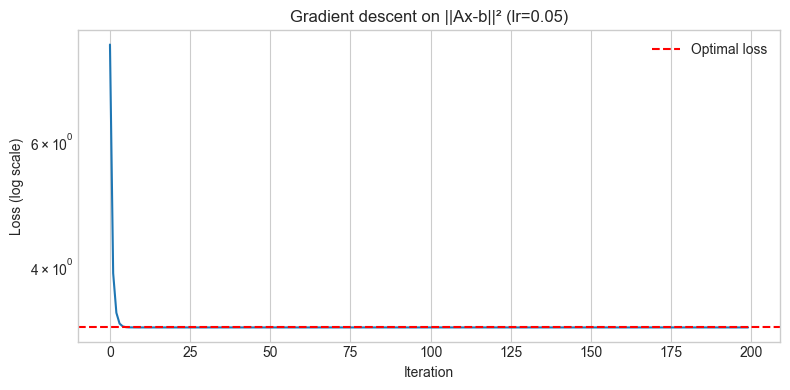

Final loss: 3.285170
Optimal loss: 3.285170


In [4]:
# --- Experiment 1: Gradient descent on ||Ax - b||^2 ---
# Hypothesis: Following the negative gradient converges to the least-squares solution
# Try changing: LEARNING_RATE

import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

LEARNING_RATE = 0.05  # try: 0.001, 0.01, 0.05, 0.2 (instability!)
N_STEPS = 200

np.random.seed(0)
A = np.random.randn(10, 3)
b = np.random.randn(10)
x = np.zeros(3)

x_star = np.linalg.lstsq(A, b, rcond=None)[0]

losses = []
for _ in range(N_STEPS):
    residual = A @ x - b
    loss = residual @ residual
    grad = 2 * A.T @ residual
    x = x - LEARNING_RATE * grad
    losses.append(loss)

plt.figure(figsize=(8, 4))
plt.semilogy(losses)
plt.axhline(np.sum((A @ x_star - b)**2), color='red', ls='--', label='Optimal loss')
plt.xlabel('Iteration')
plt.ylabel('Loss (log scale)')
plt.title(f'Gradient descent on ||Ax-b||² (lr={LEARNING_RATE})')
plt.legend()
plt.tight_layout()
plt.show()
print(f"Final loss: {losses[-1]:.6f}")
print(f"Optimal loss: {np.sum((A @ x_star - b)**2):.6f}")

## 7. Exercises

**Easy 1.** Verify analytically and numerically: ∂(||x||²)/∂x = 2x. Use `gradient_check` on a 5-dimensional example.

**Easy 2.** What is the gradient of f(x) = cᵀx with respect to x (where c is a constant vector)? Verify numerically.

**Medium 1.** Derive the gradient of f(W) = ||WX - Y||_F² with respect to W, where X is n×p, Y is m×p, and W is m×n. Verify your result with `gradient_check` on a concrete 3×4 example.

**Medium 2.** Implement gradient descent to minimize the regularized loss f(x) = ||Ax - b||² + λ||x||². The analytic gradient is 2Aᵀ(Ax-b) + 2λx. Compare the solution to the closed form: x* = (AᵀA + λI)⁻¹Aᵀb. Try λ = 0, 0.1, 1.0, 10.

**Hard.** The cross-entropy loss is L = -Σᵢ yᵢ log(softmax(Wx)ᵢ). Derive ∂L/∂(Wx) (the gradient of cross-entropy w.r.t. the pre-softmax scores). Verify numerically using finite differences.

## 8. Mini Project: Least Squares via Gradient Descent

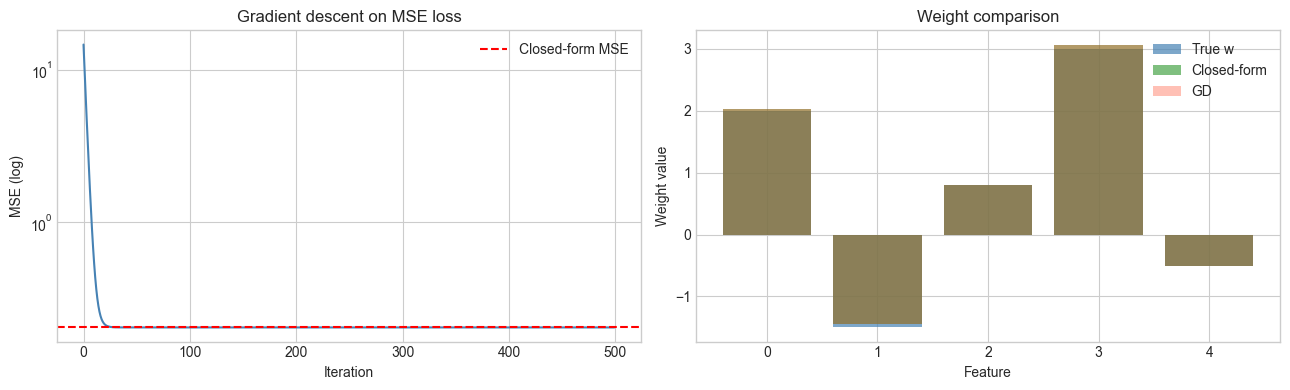

||w_closed - w_true||: 0.0983
||w_gd - w_true||:     0.0983


In [5]:
# --- Mini Project: Matrix calculus in action — linear regression by gradient descent ---
# Problem: Fit a linear model y = Xw to data using gradient descent,
#          and compare to the closed-form solution from ch182.

import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

np.random.seed(42)

# Generate synthetic regression data
n, p = 100, 5
X = np.random.randn(n, p)
w_true = np.array([2.0, -1.5, 0.8, 3.0, -0.5])
y = X @ w_true + 0.5 * np.random.randn(n)

# Closed-form solution: w* = (X^T X)^{-1} X^T y
w_closed = np.linalg.solve(X.T @ X, X.T @ y)

# Gradient descent: grad_w = 2/n X^T (Xw - y)
LR = 0.1
N_ITER = 500
w_gd = np.zeros(p)
losses_gd = []

for _ in range(N_ITER):
    residual = X @ w_gd - y
    loss = np.mean(residual**2)
    grad = (2/n) * X.T @ residual
    w_gd = w_gd - LR * grad
    losses_gd.append(loss)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].semilogy(losses_gd, color='steelblue')
axes[0].axhline(np.mean((X @ w_closed - y)**2), color='red', ls='--', label='Closed-form MSE')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('MSE (log)')
axes[0].set_title('Gradient descent on MSE loss')
axes[0].legend()

axes[1].bar(range(p), w_true, alpha=0.7, label='True w', color='steelblue')
axes[1].bar(range(p), w_closed, alpha=0.5, label='Closed-form', color='green')
axes[1].bar(range(p), w_gd, alpha=0.4, label='GD', color='tomato')
axes[1].set_xlabel('Feature')
axes[1].set_ylabel('Weight value')
axes[1].set_title('Weight comparison')
axes[1].legend()

plt.tight_layout()
plt.show()
print(f"||w_closed - w_true||: {np.linalg.norm(w_closed - w_true):.4f}")
print(f"||w_gd - w_true||:     {np.linalg.norm(w_gd - w_true):.4f}")

## 9. Chapter Summary & Connections

- Matrix calculus extends derivatives to vector and matrix inputs/outputs. Shape of gradient = shape of input.
- Key identity: ∂(||Ax-b||²)/∂x = 2Aᵀ(Ax-b) — the gradient of the squared loss.
- ∂(Wx)/∂x = Wᵀ — the Jacobian of a linear layer is its transpose.
- Numerical gradient checking via finite differences is the standard validation tool for analytic gradients.
- Gradient descent on the least-squares loss converges to the same solution as the closed-form normal equations.

**Backward:** Uses ch155 (Transpose) and ch168 (Projection) throughout. The least-squares problem in the mini project connects to ch182.

**Forward:**
- ch177 (Linear Algebra for Neural Networks): the chain rule in matrix form — backpropagation
- ch178 (Linear Layers in Deep Learning): implementing a neural layer from scratch using these gradients
- ch212 (Gradient Descent): full treatment of optimization via gradients in Part VII
- ch216 (Backpropagation): the chain rule applied through arbitrary computational graphs

**Going deeper:** The Matrix Cookbook (Petersen & Pedersen) is the reference for matrix derivative identities. For autodiff, see ch208 (Automatic Differentiation) in Part VII.